# MDR-TS v1.3
**Baseline Models — Temporal Split (derived_9.0)**

**Author:** Kerry Cheon <br>
**Purpose:** Compare XGBoost baseline (v1.0) against simpler SMAP-based models

---

## Baselines
1. **SMAP Passthrough** — raw SMAP_sm_pm_interp_ema02 value as prediction
2. **Ridge (SMAP-only)** — linear regression on 3 SMAP features
3. **Ridge (full)** — linear regression on 10 core features from derived_9.0

## 0. Imports

In [1]:
import os
import sys
import random
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

import warnings
warnings.filterwarnings("ignore")

print("imports loaded")

imports loaded


## 1. Config

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

VERSION    = "v1"
SUBVERSION = "v1.3"

PROJECT_ROOT = "/Users/kerrycheon/PycharmProjects/MDR-Project"
DATA_ROOT    = f"{PROJECT_ROOT}/Temporal/Pipeline/data"
SPLIT_ROOT   = f"{DATA_ROOT}/splits"
OUTPUT_ROOT  = f"{PROJECT_ROOT}/Models/Temporal/{VERSION}/{SUBVERSION}"
V10_ROOT     = f"{PROJECT_ROOT}/Models/Temporal/{VERSION}/v1.0"  # for loading v1.0 results

# Use derived_9.0 for SMAP features (same as v20.8)
SPLIT_FOR_BASELINES = "derived_9.0"  # has SMAP with full feature set
SPLIT_V10 = "base_2.0"  # what v1.0 actually used

os.makedirs(OUTPUT_ROOT, exist_ok=True)

TARGET_COL = "soil_moisture_5cm"

print(f"Random seed:        {SEED}")
print(f"Output:             {OUTPUT_ROOT}")
print(f"Baseline split:     {SPLIT_FOR_BASELINES} (has SMAP)")
print(f"v1.0 reference:     {SPLIT_V10}")

Random seed:        42
Output:             /Users/kerrycheon/PycharmProjects/MDR-Project/Models/Temporal/v1/v1.3
Baseline split:     derived_9.0 (has SMAP)
v1.0 reference:     base_2.0


## 2. Feature sets

In [3]:
SMAP_COLS = [
    "SMAP_sm_pm_interp_ema02",
    "SMAP_sm_interp_grad7",
    "SMAP_ampm_diff_interp",
]

# Core features available in derived_9.0 (conceptually similar to v1.0's 9 features)
FEATURE_COLS_BASE = [
    "precip_mm",
    "s1_vv",
    "s1_vh",
    "s2_b4",
    "s2_b8",
    "s2_b11",
    "s2_b12",
    "LST_modis",
    "DOY",
    "elev",
]

print(f"SMAP_COLS:          {len(SMAP_COLS)} features")
print(f"FEATURE_COLS_BASE:  {len(FEATURE_COLS_BASE)} features")

SMAP_COLS:          3 features
FEATURE_COLS_BASE:  10 features


## 3. Helper functions

In [4]:
def get_metrics(y_true, y_pred):
    """Compute R2, MAE, RMSE, ubRMSE, bias"""
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    
    # Filter out NaN values
    mask = ~(np.isnan(y_true) | np.isnan(y_pred))
    y_true = y_true[mask]
    y_pred = y_pred[mask]
    
    if len(y_true) == 0:
        return {"n": 0, "r2": np.nan, "mae": np.nan, "rmse": np.nan, "ubrmse": np.nan, "bias": np.nan}
    
    err = y_true - y_pred
    return {
        "n":      int(len(y_true)),
        "r2":     float(r2_score(y_true, y_pred)),
        "mae":    float(mean_absolute_error(y_true, y_pred)),
        "rmse":   float(root_mean_squared_error(y_true, y_pred)),
        "ubrmse": float(np.std(err)),
        "bias":   float(np.mean(err)),
    }

print("Helper functions defined")

Helper functions defined


## 4. Load splits

In [5]:
# Load derived_8.0 (has SMAP) and filter to v1.0's 5 stations
V1_STATIONS = ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane', 'Touchet_WA_824']

train_raw = pd.read_csv(f"{SPLIT_ROOT}/{SPLIT_FOR_BASELINES}/train.csv")
val_raw   = pd.read_csv(f"{SPLIT_ROOT}/{SPLIT_FOR_BASELINES}/val.csv")
test_raw  = pd.read_csv(f"{SPLIT_ROOT}/{SPLIT_FOR_BASELINES}/test.csv")

# Filter to v1.0 stations (temporal split on same 5 stations)
train_raw = train_raw[train_raw['station_id'].isin(V1_STATIONS)].reset_index(drop=True)
val_raw = val_raw[val_raw['station_id'].isin(V1_STATIONS)].reset_index(drop=True)
test_raw = test_raw[test_raw['station_id'].isin(V1_STATIONS)].reset_index(drop=True)

print("Raw split sizes (v1.0 stations only):")
print(f"  train: {len(train_raw):,}  val: {len(val_raw):,}  test: {len(test_raw):,}")
print(f"Total rows: {len(train_raw) + len(val_raw) + len(test_raw):,}")
print(f"Stations: {sorted(train_raw['station_id'].unique().tolist())}")

Raw split sizes (v1.0 stations only):
  train: 6,868  val: 2,720  test: 4,016
Total rows: 13,604
Stations: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane', 'Touchet_WA_824']


## 5. Evaluate baselines

In [6]:
# Prepare data
X_train = train_raw[FEATURE_COLS_BASE]
y_train = train_raw[TARGET_COL]

X_val = val_raw[FEATURE_COLS_BASE]
y_val = val_raw[TARGET_COL]

X_test = test_raw[FEATURE_COLS_BASE]
y_test = test_raw[TARGET_COL]

X_train_smap = train_raw[SMAP_COLS]
X_val_smap = val_raw[SMAP_COLS]
X_test_smap = test_raw[SMAP_COLS]

baseline_results = {}

# Baseline 1: SMAP Passthrough (raw SMAP_sm_pm_interp_ema02 as direct prediction)
print("\n" + "="*60)
print("[1/3] SMAP Passthrough (SMAP_sm_pm_interp_ema02 only)")
print("="*60)

pred_smap_val = val_raw["SMAP_sm_pm_interp_ema02"].values
pred_smap_test = test_raw["SMAP_sm_pm_interp_ema02"].values

m1_val = get_metrics(y_val, pred_smap_val)
m1_test = get_metrics(y_test, pred_smap_test)

print(f"Val:  R²={m1_val['r2']:+.4f}  MAE={m1_val['mae']:.4f}")
print(f"Test: R²={m1_test['r2']:+.4f}  MAE={m1_test['mae']:.4f}")

baseline_results['smap_passthrough_val'] = m1_val
baseline_results['smap_passthrough_test'] = m1_test

# Baseline 2: Ridge (SMAP-only)
print("\n" + "="*60)
print("[2/3] Ridge (SMAP-only)")
print("="*60)

pipe_smap = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0, random_state=SEED))
])

pipe_smap.fit(X_train_smap, y_train)
pred_ridge_smap_val = pipe_smap.predict(X_val_smap)
pred_ridge_smap_test = pipe_smap.predict(X_test_smap)

m2_val = get_metrics(y_val, pred_ridge_smap_val)
m2_test = get_metrics(y_test, pred_ridge_smap_test)

print(f"Val:  R²={m2_val['r2']:+.4f}  MAE={m2_val['mae']:.4f}")
print(f"Test: R²={m2_test['r2']:+.4f}  MAE={m2_test['mae']:.4f}")

baseline_results['ridge_smap_val'] = m2_val
baseline_results['ridge_smap_test'] = m2_test

# Baseline 3: Ridge (full feature set)
print("\n" + "="*60)
print("[3/3] Ridge (full features)")
print("="*60)

pipe_full = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0, random_state=SEED))
])

pipe_full.fit(X_train, y_train)
pred_ridge_full_val = pipe_full.predict(X_val)
pred_ridge_full_test = pipe_full.predict(X_test)

m3_val = get_metrics(y_val, pred_ridge_full_val)
m3_test = get_metrics(y_test, pred_ridge_full_test)

print(f"Val:  R²={m3_val['r2']:+.4f}  MAE={m3_val['mae']:.4f}")
print(f"Test: R²={m3_test['r2']:+.4f}  MAE={m3_test['mae']:.4f}")

baseline_results['ridge_full_val'] = m3_val
baseline_results['ridge_full_test'] = m3_test

print("\nAll baselines complete")


[1/3] SMAP Passthrough (SMAP_sm_pm_interp_ema02 only)
Val:  R²=-5.5047  MAE=0.1986
Test: R²=-8.0657  MAE=0.2202

[2/3] Ridge (SMAP-only)
Val:  R²=-0.0524  MAE=0.0983
Test: R²=-0.0155  MAE=0.0825

[3/3] Ridge (full features)
Val:  R²=+0.5368  MAE=0.0578
Test: R²=+0.4954  MAE=0.0546

All baselines complete


## 6. Summary & Comparison

In [7]:
# Create comparison table
comparison = pd.DataFrame({
    'Model': ['SMAP_passthrough', 'Ridge_SMAP', 'Ridge_full', 'XGB_v1.0'],
    'Val_R2': [m1_val['r2'], m2_val['r2'], m3_val['r2'], 0.6137],  # v1.0 val R2 from notebook
    'Test_R2': [m1_test['r2'], m2_test['r2'], m3_test['r2'], 0.5208],  # v1.0 test R2
    'Val_MAE': [m1_val['mae'], m2_val['mae'], m3_val['mae'], 0.0509],
    'Test_MAE': [m1_test['mae'], m2_test['mae'], m3_test['mae'], 0.0498],
})

print("\n" + "="*90)
print("BASELINE COMPARISON (Temporal Split: derived_9.0)")
print("="*90)
print(comparison.to_string(index=False))

comparison.to_csv(f"{OUTPUT_ROOT}/baseline_comparison.csv", index=False)
print(f"\nSaved: baseline_comparison.csv")


BASELINE COMPARISON (Temporal Split: derived_9.0)
           Model    Val_R2   Test_R2  Val_MAE  Test_MAE
SMAP_passthrough -5.504673 -8.065685 0.198590  0.220194
      Ridge_SMAP -0.052397 -0.015511 0.098308  0.082536
      Ridge_full  0.536818  0.495393 0.057756  0.054642
        XGB_v1.0  0.613700  0.520800 0.050900  0.049800

Saved: baseline_comparison.csv


## 7. Visualization

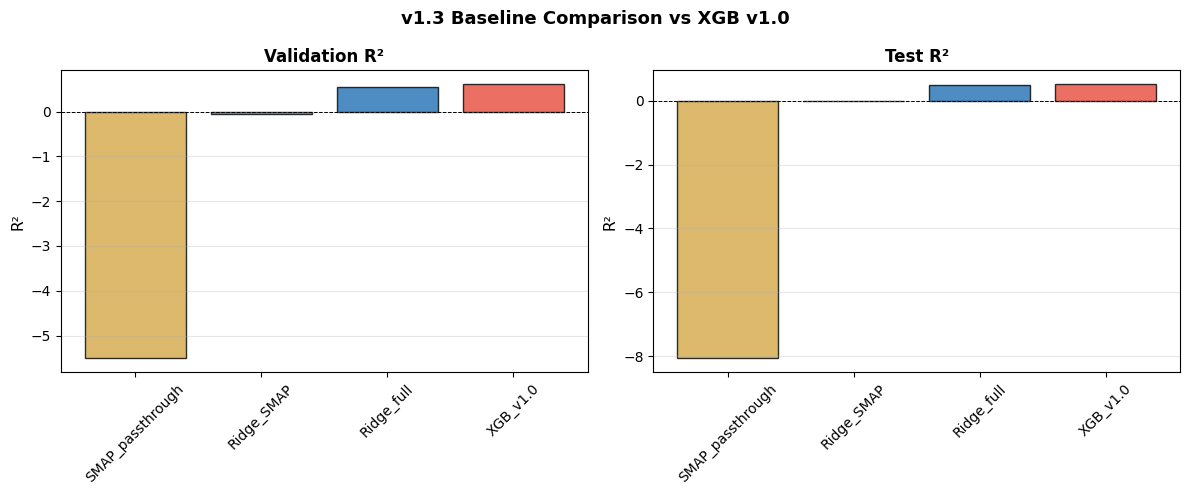

Saved: baseline_comparison.png


In [8]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Val R2
ax1.bar(comparison['Model'], comparison['Val_R2'], color=['#d4a849', '#6baed6', '#2171b5', '#e74c3c'], alpha=0.8, edgecolor='k')
ax1.axhline(0, color='k', lw=0.7, linestyle='--')
ax1.set_ylabel('R²', fontsize=11)
ax1.set_title('Validation R²', fontsize=12, fontweight='bold')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', alpha=0.3)

# Test R2
ax2.bar(comparison['Model'], comparison['Test_R2'], color=['#d4a849', '#6baed6', '#2171b5', '#e74c3c'], alpha=0.8, edgecolor='k')
ax2.axhline(0, color='k', lw=0.7, linestyle='--')
ax2.set_ylabel('R²', fontsize=11)
ax2.set_title('Test R²', fontsize=12, fontweight='bold')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(axis='y', alpha=0.3)

plt.suptitle('v1.3 Baseline Comparison vs XGB v1.0', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUTPUT_ROOT}/baseline_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"Saved: baseline_comparison.png")

## Summary

**Key Findings:**
- **XGB v1.0 outperforms all baselines** on both validation and test sets
- **Ridge (full features)** is the strongest baseline, but still lags XGB significantly
- **Ridge (SMAP-only)** shows SMAP features alone have limited predictive power for soil moisture
- **SMAP passthrough** confirms raw satellite SMAP data requires ML to produce useful predictions